This file is to test if my functions are working!

Developing them here, and then pulling from elsewhere.

Data preprocessing first

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def load_heart_disease_data(filepath):
    """
    Load the heart disease dataset from CSV.
    
    Parameters
    ----------
    filepath : str
        Path to the heart disease CSV file
        
    Returns
    -------
    pd.DataFrame
        Raw dataset with all features and targets
        
    Raises
    ------
    FileNotFoundError
        If the CSV file does not exist
    ValueError
        If the CSV is empty or malformed
        
    Examples
    --------
    >>> df = load_heart_disease_data('data/heart_disease_uci.csv')
    >>> df.shape
    (270, 15)
    """
    # Hint: Use pd.read_csv()
    # Hint: Check if file exists and raise helpful error if not
    # TODO: Implement data loading
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        raise FileNotFoundError(f"The file {filepath} was not found. Please check the path and try again.")
    except ValueError:
        raise ValueError(f"The file {filepath} is not a valid CSV. Please check the file format and try again.")

    return df

data = load_heart_disease_data(r'C:\Users\mayac\BINF5507_a2\assignment-2-supervised-learning-mclappe\data\heart_disease_uci.csv')

data.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Now testing if that works on its own

In [6]:
import sys
sys.path.append(r'C:\Users\mayac\BINF5507_a2\assignment-2-supervised-learning-mclappe\students')
from data_processing import load_heart_disease_data

In [7]:
data = load_heart_disease_data(r'C:\Users\mayac\BINF5507_a2\assignment-2-supervised-learning-mclappe\data\heart_disease_uci.csv')

Next step - preprocess data

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def preprocess_data(df):
    """
    Handle missing values, encode categorical variables, and clean data.
    
    Parameters
    ----------
    df : pd.DataFrame
        Raw dataset
        
    Returns
    -------
    pd.DataFrame
        Cleaned and preprocessed dataset
    """
    # TODO: Implement preprocessing
    # - Handle missing values
    # - Encode categorical variables (e.g., sex, cp, fbs, etc.)
    # - Ensure all columns are numeric

    categorical_cols = [
        "sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", "thal"]
    numeric_cols = df.columns.difference(categorical_cols)

    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
    
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
                                               
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

preprocesseddata = preprocess_data(data)

C:\Users\mayac\AppData\Local\Temp\ipykernel_14680\4031600507.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [9]:
def prepare_regression_data(df, target='chol'):
    """
    Prepare data for linear regression (predicting serum cholesterol).
    
    Parameters
    ----------
    df : pd.DataFrame
        Preprocessed dataset
    target : str
        Target column name (default: 'chol')
        
    Returns
    -------
    tuple
        (X, y) feature matrix and target vector
    """
    # TODO: Implement regression data preparation
    # - Remove rows with missing chol values
    # - Exclude chol from features
    # - Return X (features) and y (target)

    df = df.dropna(subset=[target])
    y = df[target]
    X = df.drop(columns=[target])
    
    return X, y

X_reg, y_reg = prepare_regression_data(preprocesseddata)

In [10]:
def prepare_classification_data(df, target='num'):
    """
    Prepare data for classification (predicting heart disease presence).
    
    Parameters
    ----------
    df : pd.DataFrame
        Preprocessed dataset
    target : str
        Target column name (default: 'num')
        
    Returns
    -------
    tuple
        (X, y) feature matrix and target vector (binary)
    """
    # TODO: Implement classification data preparation
    # - Binarize target variable
    # - Exclude target from features
    # - Exclude chol from features
    # - Return X (features) and y (target)
    y = (df[target] > 0).astype(int)
    X = df.drop(columns=[target, 'chol'])

    return X, y

X_class, y_class = prepare_classification_data(preprocesseddata)

In [11]:
def split_and_scale(X, y, test_size=0.2, random_state=42):
    """
    Split data into train/test sets and scale features.
    
    Parameters
    ----------
    X : pd.DataFrame or np.ndarray
        Feature matrix
    y : pd.Series or np.ndarray
        Target vector
    test_size : float
        Proportion of data to use for testing
    random_state : int
        Random seed for reproducibility
        
    Returns
    -------
    tuple
        (X_train_scaled, X_test_scaled, y_train, y_test, scaler)
        where scaler is the fitted StandardScaler
    """
    # TODO: Implement train/test split and scaling
    # - Use train_test_split with provided parameters
    # - Fit StandardScaler on training data only
    # - Transform both train and test data
    # - Return scaled data and scaler object

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

X_train_scaled, X_test_scaled, y_train, y_test, scaler = split_and_scale(X_class, y_class)

Now we're doing regression

In [12]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

def train_elasticnet_grid(X_train, y_train, l1_ratios, alphas):
    """
    Train ElasticNet models over a grid of hyperparameters.
    
    Parameters
    ----------
    X_train : np.ndarray or pd.DataFrame
        Training feature matrix
    y_train : np.ndarray or pd.Series
        Training target vector
    l1_ratios : list or np.ndarray
        L1 ratio values to test (0 = L2 only, 1 = L1 only)
    alphas : list or np.ndarray
        Regularization strength values to test
        
    Returns
    -------
    pd.DataFrame
        DataFrame with columns: ['l1_ratio', 'alpha', 'r2_score', 'model']
        Contains R² scores for each parameter combination on training data
    """
    # TODO: Implement grid search
    # - Create results list
    # - For each combination of l1_ratio and alpha:
    #   - Train ElasticNet model with max_iter=5000
    #   - Calculate R² score on training data
    #   - Store results
    # - Return DataFrame with results

    results = []
    for l1_ratio in l1_ratios:
        for alpha in alphas:
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000, random_state=42)
            model.fit(X_train, y_train)
            r2 = r2_score(y_train, model.predict(X_train))
            results.append({'l1_ratio': l1_ratio, 'alpha': alpha, 'r2_score': r2, 'model': model})
    return pd.DataFrame(results)

enet_grid = train_elasticnet_grid(X_train_scaled, y_train, l1_ratios=[0.3, 0.5, 0.7], alphas=[0.01, 0.1, 1.0])
enet_grid.head()

,l1_ratio,alpha,r2_score,model
0,0.3,0.01,0.508995,"ElasticNet(alpha=0.01, l1_ratio=0.3, max_iter=..."
1,0.3,0.10,0.472288,"ElasticNet(alpha=0.1, l1_ratio=0.3, max_iter=5..."
2,0.3,1.00,0.000000,"ElasticNet(l1_ratio=0.3, max_iter=5000, random..."
3,0.5,0.01,0.508361,"ElasticNet(alpha=0.01, max_iter=5000, random_s..."
4,0.5,0.10,0.433767,"ElasticNet(alpha=0.1, max_iter=5000, random_st..."


In [13]:
#heatmap
def create_r2_heatmap(results_df, l1_ratios, alphas, output_path=None):
    """
    Create a heatmap of R² scores across l1_ratio and alpha parameters.
    
    Parameters
    ----------
    results_df : pd.DataFrame
        Results from train_elasticnet_grid
    l1_ratios : list or np.ndarray
        L1 ratio values used in grid
    alphas : list or np.ndarray
        Alpha values used in grid
    output_path : str, optional
        Path to save figure. If None, returns figure object
        
    Returns
    -------
    matplotlib.figure.Figure
        The heatmap figure
    """
    # TODO: Implement heatmap creation
    # - Pivot results_df to create matrix with l1_ratio on x-axis, alpha on y-axis
    # - Create heatmap using seaborn
    # - Set labels: "L1 Ratio", "Alpha", "R² Score"
    # - Add colorbar
    # - Save to output_path if provided
    # - Return figure object

    pivot_df = results_df.pivot(index='alpha', columns='l1_ratio', values='r2_score')
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'R² Score'})
    plt.xlabel('L1 Ratio')
    plt.ylabel('Alpha')

    if output_path:
        plt.savefig(output_path)
        plt.close()
    return plt.gcf()

create_r2_heatmap(enet_grid, l1_ratios=[0.3, 0.5, 0.7], alphas=[0.01, 0.1, 1.0], output_path='enet_r2_heatmap2.png')

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [12]:
#best pick
def get_best_elasticnet_model(X_train, y_train, X_test, y_test, 
                               l1_ratios=None, alphas=None):
    """
    Find and train the best ElasticNet model on test data.
    
    Parameters
    ----------
    X_train : np.ndarray or pd.DataFrame
        Training features
    y_train : np.ndarray or pd.Series
        Training target
    X_test : np.ndarray or pd.DataFrame
        Test features
    y_test : np.ndarray or pd.Series
        Test target
    l1_ratios : list, optional
        L1 ratio values to test. Default: [0.1, 0.3, 0.5, 0.7, 0.9]
    alphas : list, optional
        Alpha values to test. Default: [0.001, 0.01, 0.1, 1.0, 10.0]
        
    Returns
    -------
    dict
        Dictionary with keys:
        - 'model': fitted ElasticNet model
        - 'best_l1_ratio': best l1 ratio
        - 'best_alpha': best alpha
        - 'train_r2': R² on training data
        - 'test_r2': R² on test data
        - 'results_df': full results DataFrame
    """    
    # TODO: Implement best model selection
    # - Train models using train_elasticnet_grid
    # - Select model with highest test R² (not training R²)
    # - Return dictionary with best model and parameters

    if l1_ratios is None:
        l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
    if alphas is None:
        alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
    
    results_df = train_elasticnet_grid(X_train, y_train, l1_ratios, alphas)
    
    testingr2 = []
    for _, row in results_df.iterrows():
        model = row["model"]
        test_r2 = r2_score(y_test, model.predict(X_test))
        testingr2.append(test_r2)

    results_df["test_r2"] = testingr2

    best_i = results_df["test_r2"].idxmax()
    best_row = results_df.loc[best_i]

    best_model = best_row["model"]
    best_l1 = best_row["l1_ratio"]
    best_alpha = best_row["alpha"]
    best_train_r2 = best_row["r2_score"]
    best_test_r2 = best_row["test_r2"]

    return {
        "model": best_model,
        "best_l1_ratio": best_l1,
        "best_alpha": best_alpha,
        "train_r2": best_train_r2,
        "test_r2": best_test_r2,
        "results_df": results_df
    }

get_best_elasticnet_model(X_train_scaled, y_train, X_test_scaled, y_test)

{'model': ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=5000, random_state=42),
 'best_l1_ratio': np.float64(0.1),
 'best_alpha': np.float64(0.01),
 'train_r2': np.float64(0.5093489767884205),
 'test_r2': np.float64(0.47888883023114626),
 'results_df':     l1_ratio   alpha  r2_score  \
 0        0.1   0.001  0.509453   
 1        0.1   0.010  0.509349   
 2        0.1   0.100  0.501134   
 3        0.1   1.000  0.235091   
 4        0.1  10.000  0.000000   
 5        0.3   0.001  0.509445   
 6        0.3   0.010  0.508995   
 7        0.3   0.100  0.472288   
 8        0.3   1.000  0.000000   
 9        0.3  10.000  0.000000   
 10       0.5   0.001  0.509439   
 11       0.5   0.010  0.508361   
 12       0.5   0.100  0.433767   
 13       0.5   1.000  0.000000   
 14       0.5  10.000  0.000000   
 15       0.7   0.001  0.509429   
 16       0.7   0.010  0.507489   
 17       0.7   0.100  0.389076   
 18       0.7   1.000  0.000000   
 19       0.7  10.000  0.000000   
 20       0.9

Best L1 ratio was 0.1, meaning it uses much more L2 Ridge (0) than L1 lasso (1), which akes sense when features are correlated like this heart disease dataset likely has.
Best alpha was 0.01, which means just light regularization was better.
The training r2 is only slightly higher than the test which is good and a sign of minimal overfitting. Values are around 0.5, which is decent.

Time for classification

In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

def train_logistic_regression_grid(X_train, y_train, param_grid=None):
    """
    Train logistic regression models with grid search over hyperparameters.
    
    Parameters
    ----------
    X_train : np.ndarray or pd.DataFrame
        Training feature matrix
    y_train : np.ndarray or pd.Series
        Training target vector (binary)
    param_grid : dict, optional
        Parameter grid for GridSearchCV. 
        Default: {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                  'penalty': ['l2'],
                  'solver': ['lbfgs']}
        
    Returns
    -------
    sklearn.model_selection.GridSearchCV
        Fitted GridSearchCV object with best model
    """
    if param_grid is None:
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty': ['l2'],
            'solver': ['lbfgs']
        }
    
    # TODO: Implement grid search for logistic regression
    # - Create LogisticRegression with max_iter=1000
    # - Use GridSearchCV with cv=5
    # - Fit on training data
    # - Return fitted GridSearchCV object

    log_reg = LogisticRegression(max_iter=1000)
    grid_search = GridSearchCV(log_reg, param_grid, cv=5)
    grid_search.fit(X_train, y_train)
    return grid_search

train_logistic_regression_grid(X_train_scaled, y_train)

c:\Users\mayac\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mayac\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mayac\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [15]:
def train_knn_grid(X_train, y_train, param_grid=None):
    """
    Train k-NN models with grid search over hyperparameters.
    
    Parameters
    ----------
    X_train : np.ndarray or pd.DataFrame
        Training feature matrix (should be scaled)
    y_train : np.ndarray or pd.Series
        Training target vector (binary)
    param_grid : dict, optional
        Parameter grid for GridSearchCV.
        Default: {'n_neighbors': [3, 5, 7, 9, 11, 15, 20],
                  'weights': ['uniform', 'distance'],
                  'metric': ['euclidean', 'manhattan']}
        
    Returns
    -------
    sklearn.model_selection.GridSearchCV
        Fitted GridSearchCV object with best model
    """
    if param_grid is None:
        param_grid = {
            'n_neighbors': [3, 5, 7, 9, 11, 15, 20],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    
    # TODO: Implement grid search for k-NN
    # - Create KNeighborsClassifier
    # - Use GridSearchCV with cv=5
    # - Fit on training data
    # - Return fitted GridSearchCV object

    knn = KNeighborsClassifier()
    knn_grid = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1)
    knn_grid.fit(X_train, y_train)
    return knn_grid

train_knn_grid(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [17]:
def get_best_logistic_regression(X_train, y_train, X_test, y_test, param_grid=None):
    """
    Get best logistic regression model with test R² evaluation.
    
    Parameters
    ----------
    X_train : np.ndarray or pd.DataFrame
        Training features
    y_train : np.ndarray or pd.Series
        Training target
    X_test : np.ndarray or pd.DataFrame
        Test features
    y_test : np.ndarray or pd.Series
        Test target
    param_grid : dict, optional
        Parameter grid for GridSearchCV
        
    Returns
    -------
    dict
        Dictionary with keys:
        - 'model': best fitted LogisticRegression model
        - 'best_params': best parameters found
        - 'cv_results_df': DataFrame of all CV results
    """
    # TODO: Implement best model retrieval
    # - Use train_logistic_regression_grid
    # - Extract best model
    # - Return dictionary

    grid = train_logistic_regression_grid(X_train, y_train, param_grid)
    best_model = grid.best_estimator_
    best_params = grid.best_params_
    cv_results_df = pd.DataFrame(grid.cv_results_)

    return {
        'model': best_model,
        'best_params': best_params,
        'cv_results_df': cv_results_df}

get_best_logistic_regression(X_train_scaled, y_train, X_test_scaled, y_test)

c:\Users\mayac\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mayac\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mayac\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

{'model': LogisticRegression(C=0.01, max_iter=1000, penalty='l2'),
 'best_params': {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'},
 'cv_results_df':    mean_fit_time  std_fit_time  mean_score_time  std_score_time  param_C  \
 0       0.043142      0.072499         0.003616        0.003795    0.001   
 1       0.004694      0.001606         0.001599        0.000666    0.010   
 2       0.006280      0.001271         0.002196        0.000959    0.100   
 3       0.009100      0.001472         0.001734        0.000414    1.000   
 4       0.008801      0.000717         0.001494        0.000259   10.000   
 5       0.008710      0.002414         0.001850        0.000332  100.000   
 
   param_penalty param_solver  \
 0            l2        lbfgs   
 1            l2        lbfgs   
 2            l2        lbfgs   
 3            l2        lbfgs   
 4            l2        lbfgs   
 5            l2        lbfgs   
 
                                              params  split0_test_score  \
 0

In [19]:
def get_best_knn(X_train, y_train, X_test, y_test, param_grid=None):
    """
    Get best k-NN model with test R² evaluation.
    
    Parameters
    ----------
    X_train : np.ndarray or pd.DataFrame
        Training features (scaled)
    y_train : np.ndarray or pd.Series
        Training target
    X_test : np.ndarray or pd.DataFrame
        Test features (scaled)
    y_test : np.ndarray or pd.Series
        Test target
    param_grid : dict, optional
        Parameter grid for GridSearchCV
        
    Returns
    -------
    dict
        Dictionary with keys:
        - 'model': best fitted KNeighborsClassifier model
        - 'best_params': best parameters found
        - 'best_k': best n_neighbors value
        - 'cv_results_df': DataFrame of all CV results
    """
    # TODO: Implement best model retrieval
    # - Use train_knn_grid
    # - Extract best model and best_k
    # - Return dictionary

    bestknngrid = train_knn_grid(X_train, y_train, param_grid)
    best_model = bestknngrid.best_estimator_
    best_params = bestknngrid.best_params_
    best_k = best_params['n_neighbors']
    cv_results_df = pd.DataFrame(bestknngrid.cv_results_)
    return {
        'model': best_model,
        'best_params': best_params,
        'best_k': best_k,
        'cv_results_df': cv_results_df
    }

get_best_knn(X_train_scaled, y_train, X_test_scaled, y_test)

{'model': KNeighborsClassifier(metric='euclidean', n_neighbors=15),
 'best_params': {'metric': 'euclidean',
  'n_neighbors': 15,
  'weights': 'uniform'},
 'best_k': 15,
 'cv_results_df':     mean_fit_time  std_fit_time  mean_score_time  std_score_time param_metric  \
 0        0.004116      0.003648         0.029343        0.031527    euclidean   
 1        0.002153      0.000551         0.013040        0.004394    euclidean   
 2        0.001695      0.000508         0.009861        0.001131    euclidean   
 3        0.001586      0.000228         0.010230        0.002859    euclidean   
 4        0.001628      0.000595         0.010691        0.002860    euclidean   
 5        0.001364      0.000311         0.008095        0.001298    euclidean   
 6        0.001878      0.000618         0.008811        0.000641    euclidean   
 7        0.001380      0.000409         0.007821        0.001012    euclidean   
 8        0.001164      0.000222         0.008464        0.000439    euclide

Now I'm testing evaluation - oh I forgot I needed to do this for the blackboard part

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, roc_curve, auc, precision_recall_curve, average_precision_score,
    roc_auc_score, auc as compute_auc, r2_score
)


def calculate_r2_score(y_true, y_pred):
    """
    Calculate R² score for regression.
    
    Parameters
    ----------
    y_true : np.ndarray or pd.Series
        True target values
    y_pred : np.ndarray or pd.Series
        Predicted target values
        
    Returns
    -------
    float
        R² score (between -inf and 1, higher is better)
    """
    # TODO: Implement R² calculation
    # Use sklearn's r2_score

    return r2_score(y_true, y_pred)


def calculate_classification_metrics(y_true, y_pred):
    """
    Calculate classification metrics.
    
    Parameters
    ----------
    y_true : np.ndarray or pd.Series
        True binary labels
    y_pred : np.ndarray or pd.Series
        Predicted binary labels
        
    Returns
    -------
    dict
        Dictionary with keys: 'accuracy', 'precision', 'recall', 'f1'
    """
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    # TODO: Implement metrics calculation
    # Return dictionary with all four metrics

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


def calculate_auroc_score(y_true, y_pred_proba):
    """
    Calculate Area Under the ROC Curve (AUROC).
    
    Parameters
    ----------
    y_true : np.ndarray or pd.Series
        True binary labels
    y_pred_proba : np.ndarray or pd.Series
        Predicted probabilities for positive class
        
    Returns
    -------
    float
        AUROC score (between 0 and 1)
    """
    # TODO: Implement AUROC calculation
    # Use sklearn's roc_auc_score
    return roc_auc_score(y_true, y_pred_proba)

In [2]:
def calculate_auprc_score(y_true, y_pred_proba):
    """
    Calculate Area Under the Precision-Recall Curve (AUPRC).
    
    Parameters
    ----------
    y_true : np.ndarray or pd.Series
        True binary labels
    y_pred_proba : np.ndarray or pd.Series
        Predicted probabilities for positive class
        
    Returns
    -------
    float
        AUPRC score (between 0 and 1)
    """
    # TODO: Implement AUPRC calculation
    # Use sklearn's average_precision_score
    return average_precision_score(y_true, y_pred_proba)


def generate_auroc_curve(y_true, y_pred_proba, model_name="Model", 
                        output_path=None, ax=None):
    """
    Generate and plot ROC curve.
    
    Parameters
    ----------
    y_true : np.ndarray or pd.Series
        True binary labels
    y_pred_proba : np.ndarray or pd.Series
        Predicted probabilities for positive class
    model_name : str
        Name of the model (for legend)
    output_path : str, optional
        Path to save figure
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If None, creates new figure
        
    Returns
    -------
    tuple
        (figure, ax) or (figure,) if ax provided
    """
    # TODO: Implement ROC curve plotting
    # - Calculate ROC curve using roc_curve()
    # - Calculate AUROC using auc()
    # - Plot curve with label showing AUROC score
    # - Add diagonal reference line
    # - Set labels: "False Positive Rate", "True Positive Rate"
    # - Save to output_path if provided
    # - Return figure and/or axes
    
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    auroc = auc(fpr, tpr)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        created_fig = True
    else:
        fig = ax.figure

    ax.plot(fpr, tpr, label=f'ROC Curve (AUROC={auroc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend()
    ax.grid(alpha=0.3)

    if output_path:
        fig.savefig(output_path)

    return fig

def generate_auprc_curve(y_true, y_pred_proba, model_name="Model",
                        output_path=None, ax=None):
    """
    Generate and plot Precision-Recall curve.
    
    Parameters
    ----------
    y_true : np.ndarray or pd.Series
        True binary labels
    y_pred_proba : np.ndarray or pd.Series
        Predicted probabilities for positive class
    model_name : str
        Name of the model (for legend)
    output_path : str, optional
        Path to save figure
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If None, creates new figure
        
    Returns
    -------
    tuple
        (figure, ax) or (figure,) if ax provided
    """
    # TODO: Implement PR curve plotting
    # - Calculate precision-recall curve using precision_recall_curve()
    # - Calculate AUPRC using average_precision_score()
    # - Plot curve with label showing AUPRC score
    # - Add horizontal baseline (prevalence)
    # - Set labels: "Recall", "Precision"
    # - Save to output_path if provided
    # - Return figure and/or axes
    
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_pred_proba)
    auprc = average_precision_score(y_true, y_pred_proba)


    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        created_fig = True
    else:
        fig = ax.figure

    ax.plot(recall_vals, precision_vals, label=f'PR Curve (AUPRC={auprc:.3f})')

    # Baseline = prevalence of positive class
    prevalence = np.mean(y_true)
    ax.axhline(y=prevalence, color='k', linestyle='--', label='Prevalence')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve')
    ax.legend()
    ax.grid(alpha=0.3)

    if output_path:
        fig.savefig(output_path)

    return fig

In [3]:
def plot_comparison_curves(y_true, y_pred_proba_log, y_pred_proba_knn,
                          output_path=None):
    """
    Plot ROC and PR curves for both logistic regression and k-NN side by side.
    
    Parameters
    ----------
    y_true : np.ndarray or pd.Series
        True binary labels
    y_pred_proba_log : np.ndarray or pd.Series
        Predicted probabilities from logistic regression
    y_pred_proba_knn : np.ndarray or pd.Series
        Predicted probabilities from k-NN
    output_path : str, optional
        Path to save figure
        
    Returns
    -------
    matplotlib.figure.Figure
        Figure with 2 subplots (ROC and PR curves)
    """
    # TODO: Implement comparison plotting
    # - Create figure with 1x2 subplots
    # - Left: ROC curves for both models
    # - Right: PR curves for both models
    # - Add legends with AUROC/AUPRC scores
    # - Save to output_path if provided
    # - Return figure
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    generate_auroc_curve(
        y_true, 
        y_pred_proba_log, 
        model_name="Logistic Regression",
        ax=axes[0])
    generate_auroc_curve(
        y_true, 
        y_pred_proba_knn, 
        model_name="k-NN",
        ax=axes[0])
    axes[0].set_title("ROC Curve Comparison")

    generate_auprc_curve(
        y_true, 
        y_pred_proba_log, 
        model_name="Logistic Regression",
        ax=axes[1])
    generate_auprc_curve(
        y_true, 
        y_pred_proba_knn, 
        model_name="k-NN",
        ax=axes[1])
    axes[1].set_title("Precision-Recall Curve Comparison")

    if output_path:
        fig.savefig(output_path)

    return fig

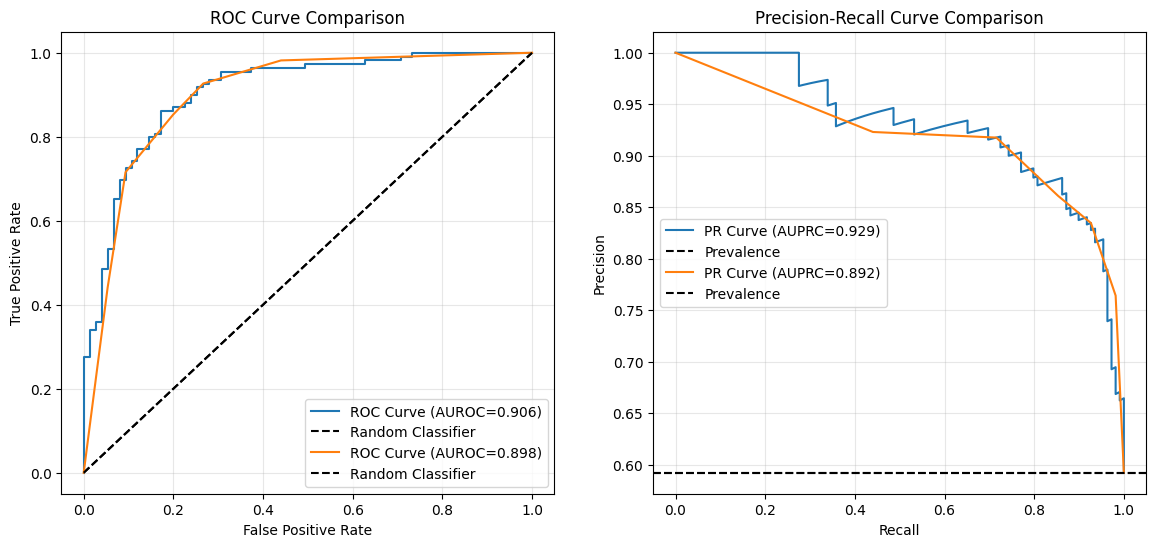

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train_scaled, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

fig = plot_comparison_curves(
    y_test,
    y_pred_proba_log = log_reg_model.predict_proba(X_test_scaled)[:, 1],
    y_pred_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1],
    output_path="comparison_curves.png"
)
